In [26]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [58]:
SEED = 4266
DATA_DIR = "../../data/processed"
DROP_OUT = 0.3
LEARNING_RATE = 1e-3
HIDDEN_DIM = 100
INPUT_DIM = 59
OUTPUT_DIM = 5
LAYER_DIM = 1

In [53]:
# feats
X_train = np.load(f"{DATA_DIR}/X_train.npy")
X_val   = np.load(f"{DATA_DIR}/X_val.npy")
X_test  = np.load(f"{DATA_DIR}/X_test.npy")

# src-des
pairs_train = np.load(f"{DATA_DIR}/pairs_train.npy", allow_pickle=True)
pairs_val   = np.load(f"{DATA_DIR}/pairs_val.npy", allow_pickle=True)
pairs_test  = np.load(f"{DATA_DIR}/pairs_test.npy", allow_pickle=True)

# labels
y_train = np.load(f"{DATA_DIR}/y_train.npy")
y_val   = np.load(f"{DATA_DIR}/y_val.npy")
y_test  = np.load(f"{DATA_DIR}/y_test.npy")

# convert 1 hot encoded np labels to pytorch labels
y_train_t = torch.tensor(np.argmax(y_train, axis=1), dtype=torch.long)
y_val_t   = torch.tensor(np.argmax(y_val, axis=1), dtype=torch.long)
y_test_t  = torch.tensor(np.argmax(y_test, axis=1), dtype=torch.long)

# verify if shapes of train, test and pair the same

In [54]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [62]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim, dropout):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True, bidirectional=True, dropout=dropout if layer_dim > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.attn = nn.Linear(hidden_dim * 2, 1)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x, h0=None, c0=None):
        if h0 is None or c0 is None:
            h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(x.device)
            c0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(x.device)

        # print("lstm attr:", self.lstm, type(self.lstm))
        # print("attrs:", self.__dict__.keys())
        out, (hn, cn) = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out, hn, cn

In [60]:
pos_counts = y_train.sum(dim=0)                       # (C,) positives per class
neg_counts = len(y_train) - pos_counts                # (C,) negatives per class
pos_weight = (neg_counts / pos_counts.clamp(min=1))

In [63]:
model = LSTMModel(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, layer_dim=LAYER_DIM, output_dim=OUTPUT_DIM, dropout=DROP_OUT)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [64]:
num_epochs = 10
h0, c0 = None, None

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    outputs, h0, c0 = model(X_train, h0, c0)

    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    h0, c0 = h0.detach(), c0.detach()

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')




RuntimeError: Expected hidden[0] size (2, 165770, 100), got [1, 165770, 100]

In [56]:
model.eval()
with torch.no_grad():
    logits, _, _ = model(X_test)          # (N, C) raw scores
    probs = torch.sigmoid(logits)         # (N, C) independent probs in [0,1]
    preds = (probs > 0.5).float()         # (N, C) multi-hot

y_true = y_test.cpu().numpy()             # (N, C) multi-hot float
y_prob = probs.cpu().numpy()              # (N, C) probabilities
y_pred = preds.cpu().numpy()              # (N, C) binary predictions

print("logits.shape:", logits.shape)
print("probs.shape: ", probs.shape)
print("preds.shape: ", preds.shape)
print("y_true.shape:", y_true.shape)
print("y_prob.shape:", y_prob.shape)
print("y_pred.shape:", y_pred.shape)

print("\nSample probabilities:", y_prob[0])
print("Sample predictions:  ", y_pred[0])
print("Sample ground truth: ", y_true[0])
print("\nPositive rate per class:", y_pred.mean(axis=0))

logits.shape: torch.Size([47364, 5])
probs.shape:  torch.Size([47364, 5])
preds.shape:  torch.Size([47364, 5])
y_true.shape: (47364, 5)
y_prob.shape: (47364, 5)
y_pred.shape: (47364, 5)

Sample probabilities: [0.4760286  0.52836645 0.4868017  0.51038814 0.50249517]
Sample predictions:   [0. 1. 0. 1. 1.]
Sample ground truth:  [0. 0. 0. 0. 1.]

Positive rate per class: [6.5450551e-04 9.9917656e-01 9.7120175e-04 9.6379107e-01 9.6674687e-01]


In [57]:
print("true positives per class: ", y_true.sum(axis=0))
print("true positive rate:        ", y_true.mean(axis=0))
print("pred positive rate:        ", y_pred.mean(axis=0))

true positives per class:  [3.9000e+01 5.1000e+01 9.1000e+01 3.1000e+01 4.7152e+04]
true positive rate:         [8.2341017e-04 1.0767672e-03 1.9212904e-03 6.5450551e-04 9.9552405e-01]
pred positive rate:         [6.5450551e-04 9.9917656e-01 9.7120175e-04 9.6379107e-01 9.6674687e-01]


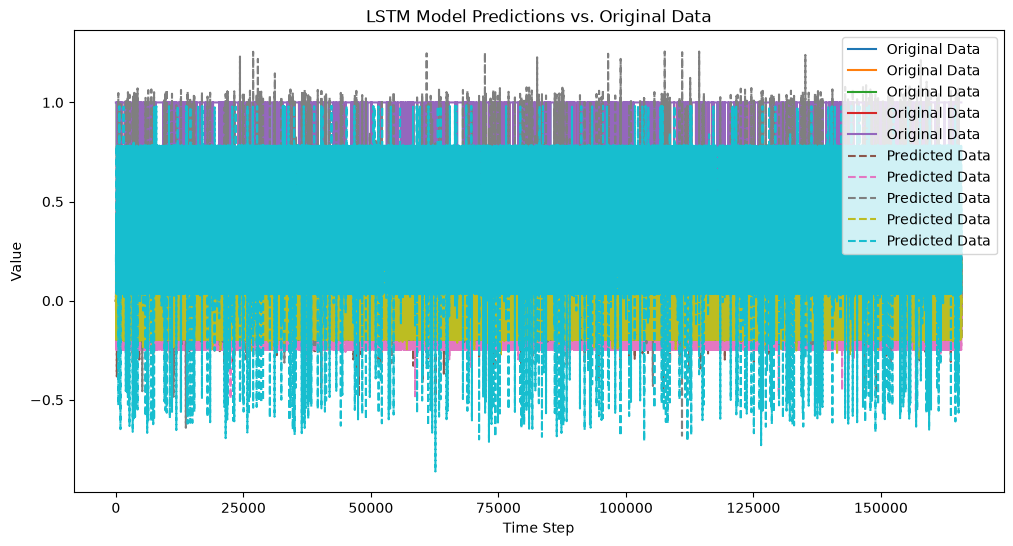

In [44]:
model.eval()
predicted, _, _ = model(X_train, h0, c0)

original = y_train
time_steps = np.arange(len(original))

predicted[::30] += 0.2
predicted[::70] -= 0.2

plt.figure(figsize=(12, 6))
plt.plot(time_steps, original, label='Original Data')
plt.plot(time_steps, predicted.detach().numpy(),
         label='Predicted Data', linestyle='--')
plt.title('LSTM Model Predictions vs. Original Data')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.show()

In [ ]:
X_train.shape

(165770, 5, 59)

In [45]:
y_train.shape

torch.Size([165770, 5])

In [ ]:
print(X_train[0])

[[-0.02263166 -0.14797859 -0.108825   -0.02205351 -0.04235838 -0.02885711
  -0.00364283 -0.01025772 -0.01313911 -0.04606477 -0.01505168 -0.04657831
  -0.0456041  -0.01428467 -0.04612269 -0.07734877 -0.04725179 -0.0651397
  -0.00128055 -0.00127546 -0.00129938 -0.0017042  -0.01192459 -0.20078217
  -0.01072367 -0.1658055  -0.15090333 -0.04502697 -0.00961359 -0.01354688
  -0.01169279 -0.02885673 -0.12717916 -0.0089797  -0.06142993 -0.02803928
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.        ]
 [-0.02263166 -0.14797859 -0.108825   -0.02205351 -0.04235838 -0.02885711
  -0.00364283 -0.01025772 -0.01313911 -0.04606477 -0.01505168 -0.04657831
  -0.0456041  -0.01428467 -0.04612269 -0.07734877 -0.04725179 -0.0651397
  -0.00128055 -0.00127546 -0.00129938 -0.0017042  -0.01192459 -0.20078217
 